In [1]:
from xgboost import XGBClassifier
#from xgboost import XGBRegressor
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv("synthetic.csv")
print(data.head())
print(data.shape)
print(data.isna().sum())
print(data["isFraud"].unique())
print(data["isFraud"].value_counts())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
(6362620, 11)
step              0
type              0
amount            0
nameOrig          0
oldbalanceO

In [3]:
use_features = ['type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']
new_df = data[use_features]
new_df.head()
new_df['isFraud'].value_counts()


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [4]:

le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])

features = ['type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
x = data[features]
y = data['isFraud']



print("Dataset shape:",x.shape)
#first 70% train,30% tempory
x_train,x_temp,y_train,y_temp = train_test_split(x,y,test_size=0.3,stratify=y,random_state=42)

x_val,x_test,y_val,y_test = train_test_split(x_temp,y_temp,test_size=0.5,stratify=y_temp,random_state=42)

print("Dataset split")
print("Training :",x_train.shape)
print("Validation :",x_val.shape)
print("Test :",x_test.shape) 

scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]



Dataset shape: (6362620, 6)
Dataset split
Training : (4453834, 6)
Validation : (954393, 6)
Test : (954393, 6)


In [5]:
model = XGBClassifier(
    max_depth = 4,
    learning_rate = 0.05,
    n_estimators = 1000,
    random_state = 42,
    subsample = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 30,
    n_jobs = -1,
    scale_pos_weight=scale_weight,
    eval_metric='aucpr',
)

In [6]:
model.fit(
    x_train,y_train,
    eval_set = [(x_train,y_train),(x_val,y_val)]
)

[0]	validation_0-aucpr:0.07403	validation_1-aucpr:0.07038
[1]	validation_0-aucpr:0.45884	validation_1-aucpr:0.46162
[2]	validation_0-aucpr:0.56240	validation_1-aucpr:0.55587
[3]	validation_0-aucpr:0.50380	validation_1-aucpr:0.50032
[4]	validation_0-aucpr:0.71523	validation_1-aucpr:0.71047
[5]	validation_0-aucpr:0.70675	validation_1-aucpr:0.70042
[6]	validation_0-aucpr:0.72674	validation_1-aucpr:0.72166
[7]	validation_0-aucpr:0.72752	validation_1-aucpr:0.72306
[8]	validation_0-aucpr:0.73147	validation_1-aucpr:0.72806
[9]	validation_0-aucpr:0.71825	validation_1-aucpr:0.71221
[10]	validation_0-aucpr:0.69804	validation_1-aucpr:0.69304
[11]	validation_0-aucpr:0.70258	validation_1-aucpr:0.69694
[12]	validation_0-aucpr:0.69832	validation_1-aucpr:0.69278
[13]	validation_0-aucpr:0.69853	validation_1-aucpr:0.69303
[14]	validation_0-aucpr:0.69789	validation_1-aucpr:0.69148
[15]	validation_0-aucpr:0.69775	validation_1-aucpr:0.69194
[16]	validation_0-aucpr:0.69788	validation_1-aucpr:0.69231
[17]	va

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
print(f"best iteration: {model.best_iteration}")

best iteration: 941


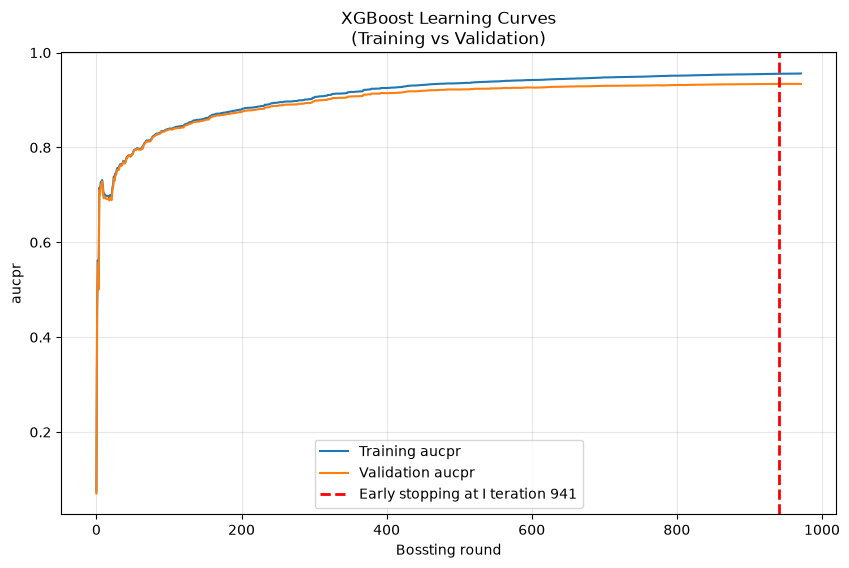

In [8]:
result = model.evals_result()
plt.figure(figsize=(10,6))
plt.plot(result['validation_0']['aucpr'],label='Training aucpr')
plt.plot(result['validation_1']['aucpr'],label='Validation aucpr')

plt.axvline(
    x=model.best_iteration,
    color = 'red',
    linestyle='--',
    linewidth=2,
    label=f'Early stopping at I teration {model.best_iteration}'
)
plt.xlabel('Bossting round')
plt.ylabel('aucpr')
plt.title('XGBoost Learning Curves\n(Training vs Validation)')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [9]:
y_test_predict = model.predict(x_test)
print(classification_report(y_test,y_test_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.26      0.99      0.42      1232

    accuracy                           1.00    954393
   macro avg       0.63      0.99      0.71    954393
weighted avg       1.00      1.00      1.00    954393



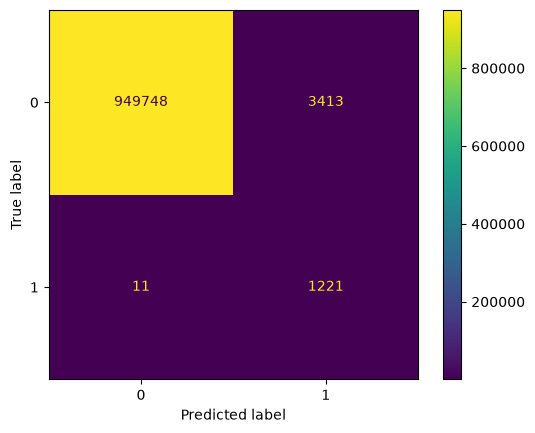

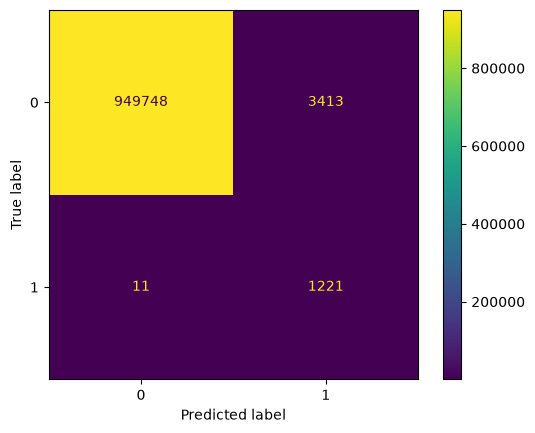

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_predict).plot()

In [11]:
print(data.loc[3])
predicted_value = model.predict(x.loc[[3]])
print(f"result: {predicted_value}")

step                       1
type                       1
amount                 181.0
nameOrig          C840083671
oldbalanceOrg          181.0
newbalanceOrig           0.0
nameDest           C38997010
oldbalanceDest       21182.0
newbalanceDest           0.0
isFraud                    1
isFlaggedFraud             0
Name: 3, dtype: object
result: [1]


In [12]:
model.save_model('xgb_paysim_model.json')
print("model saved")

model saved
